In [ ]:
from datetime import datetime
from getpass import getpass

rdm_admin_url = 'https://admin.develop.rdm.example.com/'
idp_name_1 = "GakuNin RDM IdP"
idp_username_1 = "admin_user"
idp_password_1 = "admin_password"
rdm_project_name = 'TEST-グループ管理連携機能検証-{}'.format(datetime.now().strftime('%Y%m%d'))
target_storage_name = 'NII Storage'
target_storage_id = 'osfstorage'
delete_project = True
default_result_path = None
close_on_fail = False
transition_timeout = 60000

In [2]:
if idp_username_1 is None:
    idp_username_1 = input(prompt=f'Username for {idp_name_1}')
if idp_password_1 is None:
    idp_password_1 = getpass(prompt=f'Password for {idp_username_1}@{idp_name_1}')
(len(idp_username_1), len(idp_password_1))

(7, 16)

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/tmp/tmpgjf55az7'

# アドオン利用制御

- サブシステム名: アドオン利用制御
- ページ/アドオン: アドオン利用制御-グループ管理連携機能
- 機能分類: グループ管理連携機能
- シナリオ名: 
- 用意するテストデータ: アカウント(機関管理者1)

In [4]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=False, last_path=default_result_path)

('20260327-105043', '/tmp/tmp7pv6r0v5')

## ウェブブラウザの新規プライベートウィンドウでGakunin RDM管理者のトップページを表示する

- 管理者トップページが表示されること

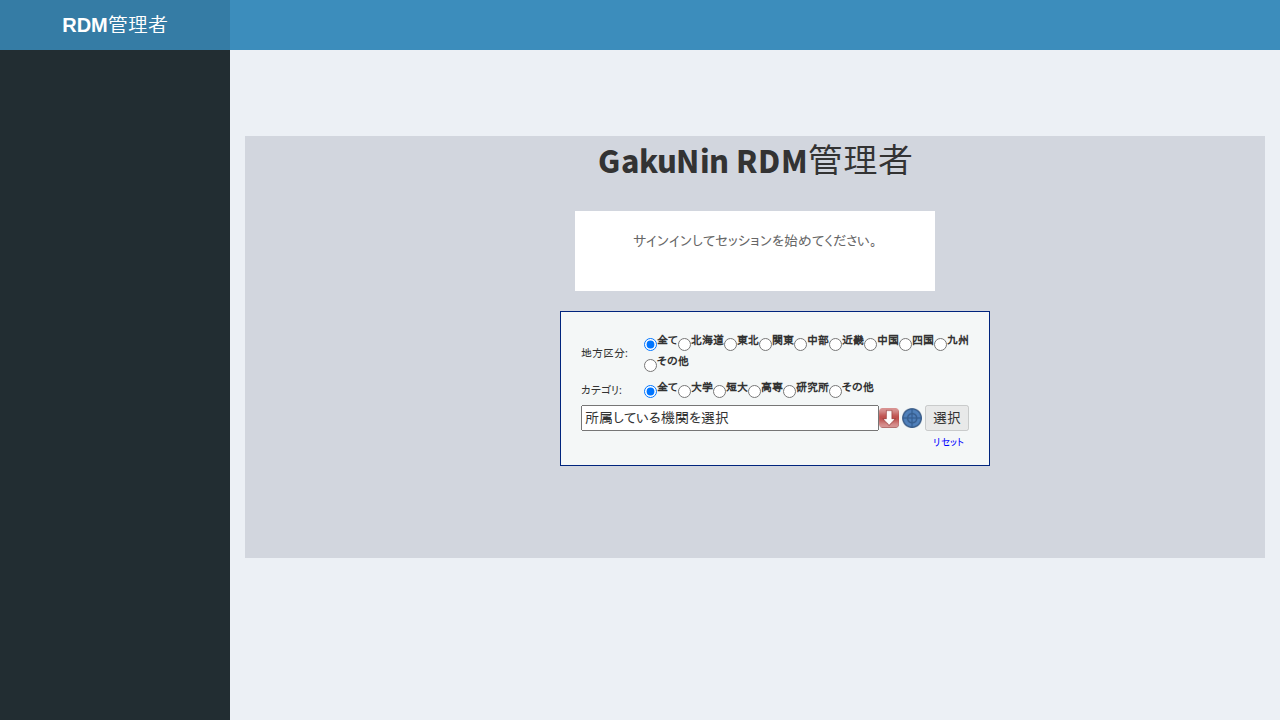

In [5]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await page.goto(rdm_admin_url)
    time.sleep(1)

await run_pw(_step)

## ログイン情報を用いてGakuNin RDMにログインする

- 管理者ページが表示されること

In [ ]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login(page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout)

    # GRDMのボタンが表示されることを確認
    await expect(page.locator('//*[text() = "GakuNin RDM機関管理者ページへようこそ"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「アドオン利用制御」を選択する

- 「アドオン利用制御」が表示されること
- 「Groups」がデフォルトで無効になっていること

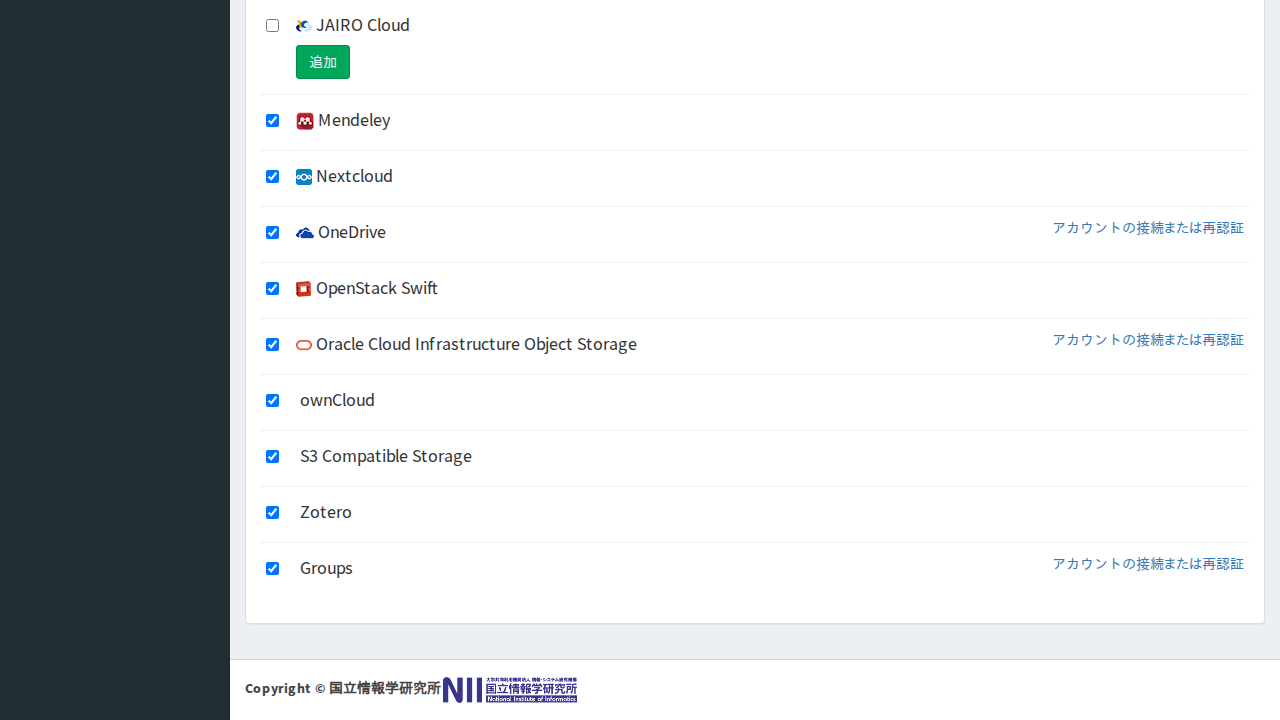

In [ ]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    # Wait for the link with the text "アドオン利用制御" to be visible
    await page.wait_for_selector('a:has-text("アドオン利用制御")')

    # Click the link
    await page.locator('a:has-text("アドオン利用制御")').click()

    # Wait for the checkbox to be present
    checkbox = page.locator('input[type="checkbox"][data-addon-short-name="groups"]')
    
    # Assert that the checkbox is not checked
    assert not await checkbox.is_checked()
    time.sleep(2)

await run_pw(_step)

## 「Groups」アドオンを有効にする

- チェックボックスがオンになること
- 「Groups」が有効になっていること

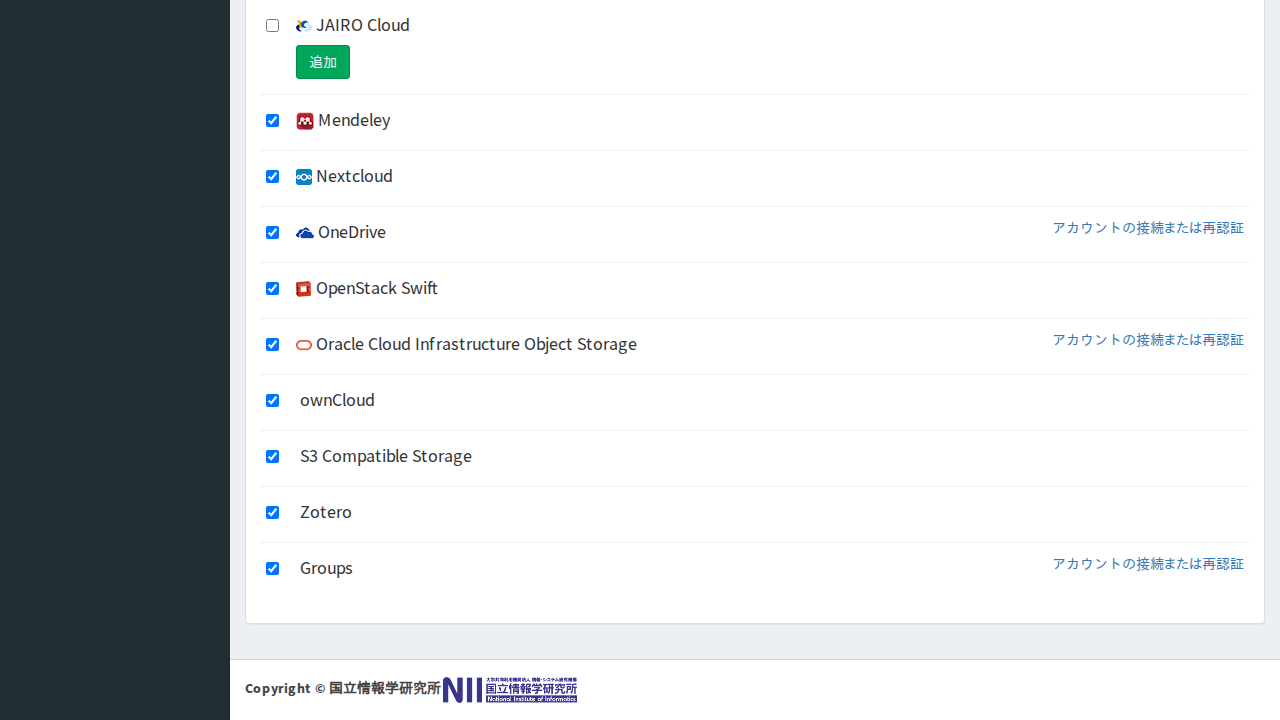

In [ ]:
async def _step(page):
    # Wait for the checkbox to be present
    checkbox = page.locator('input[type="checkbox"][data-addon-short-name="groups"]')
    await checkbox.check()

    # Assert that the checkbox is checked
    assert await checkbox.is_checked()
    time.sleep(2)

await run_pw(_step)

終了処理を実施。

In [ ]:
await finish_pw_context()

In [9]:
!rm -fr {work_dir}